### Imports

In [18]:
# import required libraries
import os
import random

from pathlib import Path
from PIL import Image
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
# from model import SignLanguageCNN

%matplotlib inline

### Hyperparameters & Configurations

In [14]:
img_size = 200
batch_size = 32
epochs = 40
lr = 0.0001

# data split ratios
train_split = 0.70
val_split = 0.15
test_split = 0.15

# data path
data_dir = "../data/asl_alphabet_train"

### Reproducibility & Device setup

In [5]:
# set random seeds
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f"All random seeds are set to {seed}")

All random seeds are set to 42


In [8]:
# device setup
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


### Load Raw Dataset & Visualise Samples

In [15]:
# Load raw dataset (without transforms)
raw_dataset = datasets.ImageFolder(root=data_dir)
num_classes = len(raw_dataset.classes)

print(f"Total No. of Classes: {num_classes}")
print(f"Classes: {raw_dataset.classes}")

Total No. of Classes: 29
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


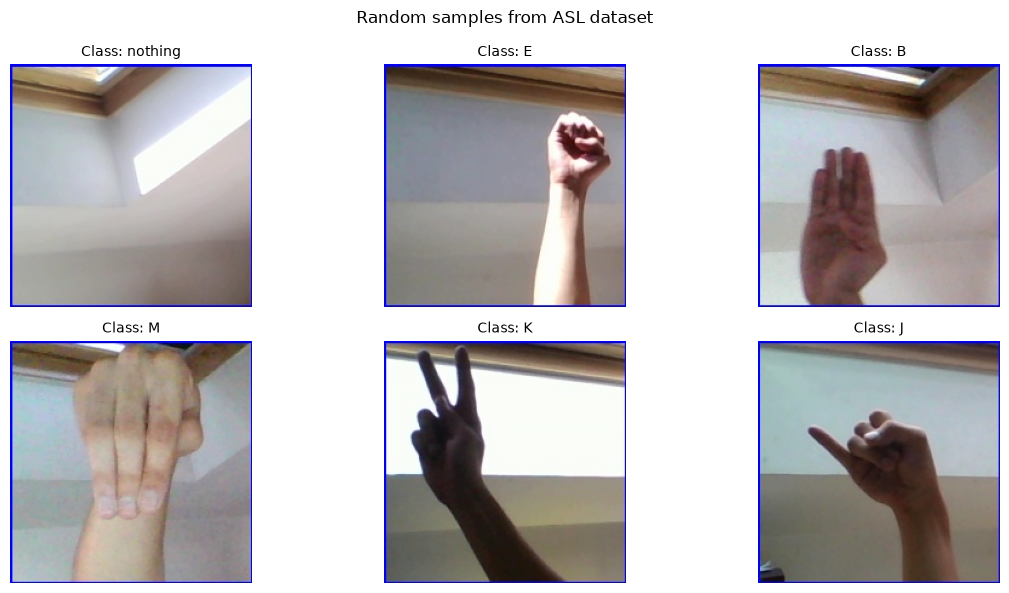

In [16]:
# visualize random samples
num_images = 6
plt.figure(figsize=(12,6))

for i in range(num_images):
    idx = random.randint(0, len(raw_dataset) - 1)
    img, label = raw_dataset[idx]
    
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(f"Class: {raw_dataset.classes[label]}", fontsize=10)
    plt.axis("off")

plt.suptitle("Random samples from ASL dataset", fontsize=12)
plt.tight_layout()
plt.show()

### Data Transforms

In [42]:
# training transforms with augmentation
train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # 1 channel
    transforms.Resize((img_size, img_size)),
    transforms.RandomAffine(15, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# validation & test transforms without augmentation
val_transforms = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

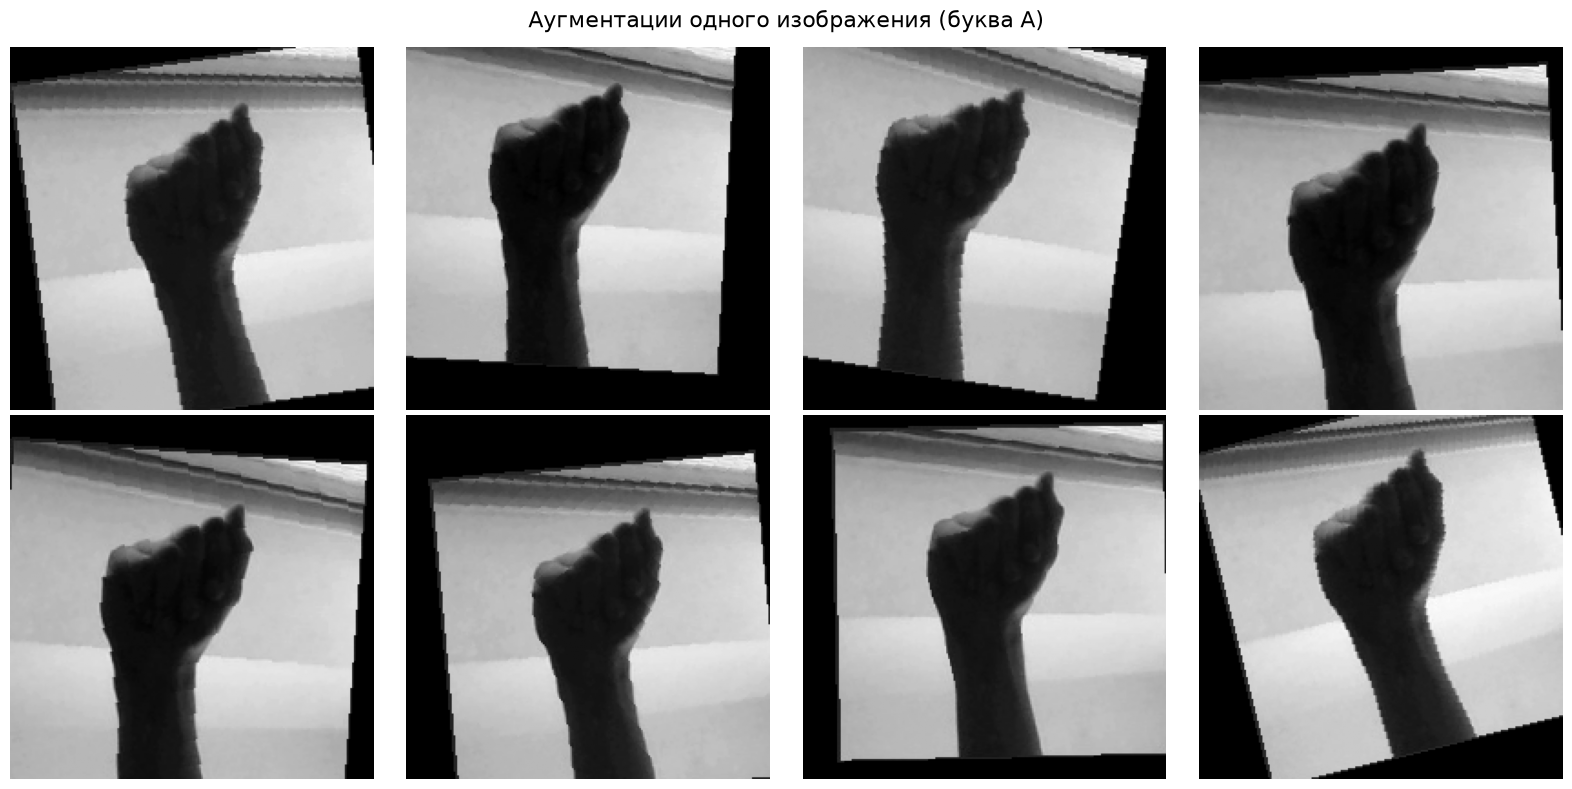

In [ ]:
img = Image.open("../data/asl_alphabet_train/A/A1.jpg").convert("RGB")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax in axes.flat:
    aug_img = train_transforms(img)
    ax.imshow(aug_img, cmap='gray')
    ax.axis("off")
plt.suptitle("Аугментации одного изображения (буква A)", fontsize=16)
plt.tight_layout()
plt.show()

### Splitting Dataset

In [49]:
# load dataset with transforms
train_data_full = datasets.ImageFolder(root=data_dir, transform=train_transforms)
# val_data_full = datasets.ImageFolder(root=data_dir, transform=val_transforms)
# test_data_full = datasets.ImageFolder(root=data_dir, transform=val_transforms)

In [50]:
# split the data
dataset_size = len(train_data_full)
train_size = int(train_split * dataset_size) # 0.7
val_size = int(val_split * dataset_size) # 0.15
test_size = dataset_size - train_size - val_size # 0.15

generator = torch.Generator().manual_seed(seed)
train_ds, val_ds, test_ds = random_split(train_data_full, [train_size, val_size, test_size], generator=generator)

print(f"Total images: {dataset_size}")
print(f"Train: {len(train_ds)} ({len(train_ds)/dataset_size:.1%})")
print(f"Val:   {len(val_ds)} ({len(val_ds)/dataset_size:.1%})")
print(f"Test:  {len(test_ds)} ({len(test_ds)/dataset_size:.1%})")

Total images: 87000
Train: 60899 (70.0%)
Val:   13050 (15.0%)
Test:  13051 (15.0%)
